<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
تشخیص رنگ
</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
در تمرین اول پروژه سوم سعی خواهیم کرد رنگ ماشین ها را تشخیص دهیم. برای راحتی و قابل حل بودن مسئله، صورت سوال به این شکل است که در نهایت تابعی نوشته شود که تشخیص دهد ماشین سیاه است یا سفید! و چه داده هایی که در اختیار شما قرار گرفته چه داده های سیستم داوری شامل تصاویری از ماشین ها به رنگ سیاه و سفید هستند. دوباره یادآوری میشود که این دسته از مسائل در دنیای وافعی به کمک شبکه های عصبی و مفاهیم بینایی کامپیوتر حل میشوند.
</font>
</p>

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
اضافه کردن کتابخانه های مورد نیاز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
با اجرای سلول زیر تمام کتابخانه هایی که در طول این تمرین نیاز خواهد شد، import میشوند.
</font>
</p>

In [79]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
بارگذاری تصویر 
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
در این سلول میتوانید با استفاده از <code>opencv</code> تصاویری که در طول حل مسئله به آن نیاز دارید را بارگذاری کنید.
</font>
</p>

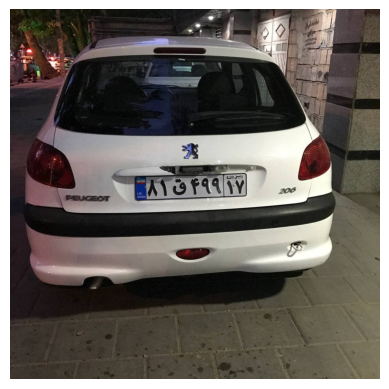

In [80]:
# Read the image
image = cv2.imread('../Data/200.png')

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
در سلول زیر، تابع <code>show_image</code> را بنویسید. ورودی این تابع تصویر و <code>cmap</code> است. اگر <code>cmap</code> مقدار <code>gray</code> داشت تصویر بصورت باینری یا سطح خاکستری نمایش داده میشود و در غیر اینصورت تصویر بصورت رنگی و با فرمت <code>RGB</code> نمایش داده شود.
</font>
</p>

In [81]:
def show_image(image, title, cmap=None):
    if cmap == 'gray':
        if image.ndim == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
        plt.show()
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
        plt.show()


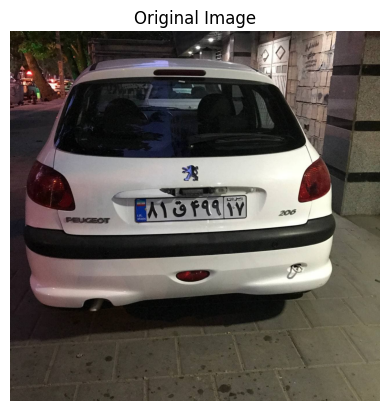

In [82]:
show_image(image, 'Original Image', cmap = None)

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
در سلول زیر تابع <code>normalize_brightness</code> را بنویسید. هدف از پیاده سازی این تابع بهبود روشنایی و کنتراست تصویر است. برای مثال در این تابع میتوانید هموارسازی هیستوگرام یا عملیاتی از این دست را پیاده سازی کنید. دقت کنید که وجود این تابع تاثیر بسزایی در خروجی نهایی دارد. اگرچه بصورت اختیاری مطرح شده اما برای امتحان میتوانید در انتهای مسئله یکبار با تابع نرمال ساز و یک بار بدون تابع نرمال ساز برنامه، خروجی برنامه خود را مقایسه کنید. (در تنظیم پارامترهای این تابع دقت به خرج دهید.)
</font>
</p>

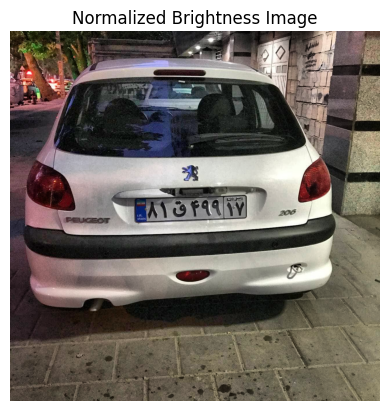

In [83]:
"""
def normalize_brightness(image):
    h, s, v = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))
    v = cv2.normalize(v, None, alpha=30, beta=220, norm_type=cv2.NORM_MINMAX)
    return cv2.cvtColor(cv2.merge((h, s, v)), cv2.COLOR_HSV2BGR)
"""

def normalize_brightness(image):
    h, s, v = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    v = clahe.apply(v)

    return cv2.cvtColor(cv2.merge((h, s, v)), cv2.COLOR_HSV2BGR)


normal_image = normalize_brightness(image)
show_image(normal_image, 'Normalized Brightness Image')

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
تصویر را ابتدا به سطح خاکستری و سپس با استفاده از تکنیک <code>Otsu</code> به باینری تبدیل کنید و با تابع <code>show_image</code> آن را رسم کنید.
</font>
</p>

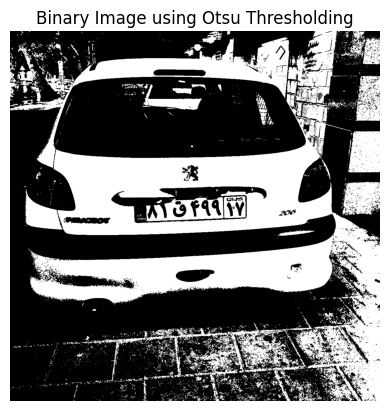

In [84]:
gray_image = cv2.cvtColor(normal_image, cv2.COLOR_BGR2GRAY)
otsu_threshold, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_image(binary_image, 'Binary Image using Otsu Thresholding', cmap='gray')

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
از آنجایی که ما مدل بینایی ماشین نداریم که با دقت خیلی بالایی بتواند محل قرار گیری ماشین و حتی نوع ماشین را تشخیص دهد! باید بصورت ضمنی قسمتی از تصویر که احتمال میدهیم احتمالا ماشین آنجا باشد را جدا کنیم و با شمارش پیکسل های آن ناحیه جدا شده (پیکسل های سفید و سیاه) رنگ ماشین را تشخیص دهیم. بدین منظور در این سلول ناحیه ای تحت عنوان ماسک طراحی کنید. برای مثال  برای حل این سوال تیم طراحی هشتاد درصد میانه تصویر را به عنوان ماسک انتخاب کرد. یعنی چه؟ یعنی 20 درصد از بالا پایین چپ و راست تصویر را نادیده گرفته و همان هشتاد درصد میانی را شمارش پیکسل انجام دادند تا رنگ ماشین را تشخیص دهند. با این منطق که احتمال خیلی بالا ماشین در همان 80 درصد ناحیه میانی است. در سلول زیر هم ناحیه ای تحت عنوان ماسک در تصویر تعریف کنید که در الگوریتمتان به ازای هر تصویری، همان ناحیه ماسک شده پیکسل هایش شمرده شوند. (برای انتخاب پارامترهای مناسب، دوباره میتوانید از تصاویری که در اختیارتان قرارگرفته استفاده کنید.)
</font>
</p>

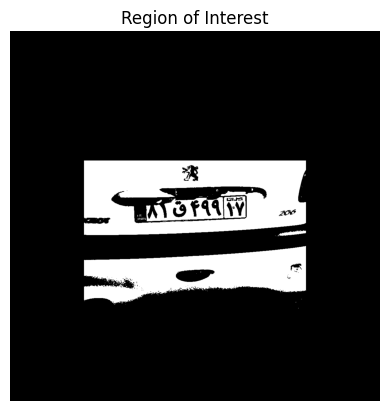

In [91]:
h , w = binary_image.shape
mask = np.zeros((h, w), np.uint8)
x1, x2 = int(0.2 * w), int(0.8 * w)
y1, y2 = int(0.35 * h), int(0.75 * h)
mask[y1:y2, x1:x2] = 1

roi = binary_image * mask
show_image(roi, 'Region of Interest', cmap='gray')

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
قسمت ماسک را crop کنید و به کمک تابعی که نوشتید رسم کنید.
</font>
</p>

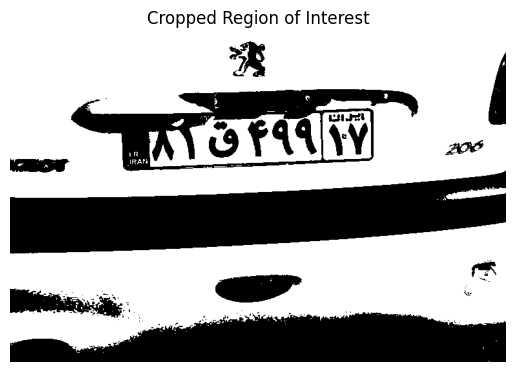

In [92]:
cropped_region = binary_image[y1:y2, x1:x2]
show_image(cropped_region, 'Cropped Region of Interest', cmap='gray')

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
تعداد پیکسل های سفید و سیاه را در متغیر <code>cropped_region</code> و مقایسه کنید.
</font>
</p>

In [93]:
"""
v = cv2.cvtColor(cropped_region, cv2.COLOR_BGR2HSV)[:, :, 2]
mean_v = np.mean(v)

if mean_v > 140:
    color = "white"
else:
    color = "black"
print(color)
"""

white_pixels = np.sum(cropped_region == 255)
black_pixels = np.sum(cropped_region == 0)
print(f"Number of white pixels: {white_pixels}")
print(f"Number of black pixels: {black_pixels}")


Number of white pixels: 247066
Number of black pixels: 146150


<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
نوشتن تابع نهایی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
حال تابع <code>color_recognition</code> را تکمیل کنید در نهایت این تابع باید به ازای تصویر ماشین رنگ مربوطه را return کند.
</font>
</p>

In [88]:
def color_recognition(image):

    # --- normalize_brightness (inline) ---
    h, s, v = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    v = clahe.apply(v)

    normal_image = cv2.cvtColor(cv2.merge((h, s, v)), cv2.COLOR_HSV2BGR)
    # ------------------------------------

    # gray + otsu (فقط برای کمک)
    gray = cv2.cvtColor(normal_image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    h, w = binary.shape

    # ROI بدنه
    x1, x2 = int(0.2 * w), int(0.8 * w)
    y1, y2 = int(0.35 * h), int(0.75 * h)

    # ROI رنگی (نه باینری!)
    roi_color = binary[y1:y2, x1:x2]
    white_pixels = np.sum(roi_color == 255)
    black_pixels = np.sum(roi_color == 0)
    

    return "white" if white_pixels > black_pixels else "black"


<h3 align=right style="line-height:200%;font-family:vazir;" dir=rtl>
<font face="vazirmatn" color="#0099cc">
<b>توجه:</b>
</font>
اگر از تابع <code>normalize_brightness</code> استفاده کردید لطفا بدنه تابع را در تابع نهایی کپی کنید. در نهایت تنها تابع نهایی داوری میشود!
</h3>


In [89]:
image = cv2.imread('../Data/299.png')
detected_color = color_recognition(image)
print(f"The detected color is: {detected_color}")

The detected color is: white


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد. دقت کنید نام تابع حتما <code>calculation</code>  باشد و لطفا فایل <code>result.zip</code> را در نهایت در سایت بارگذاری کنید.

</font>
</p>

In [90]:
import zipfile
from inspect import getsource


def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

imp = """
import cv2
import numpy as np
"""

%save color_recognition imp + getsource(color_recognition)


file_names = ["color_recognition.py", "NoteBook.ipynb"]
compress(file_names)

The following commands were written to file `color_recognition.py`:

import cv2
import numpy as np
def color_recognition(image):

    # --- normalize_brightness (inline) ---
    h, s, v = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    v = clahe.apply(v)

    normal_image = cv2.cvtColor(cv2.merge((h, s, v)), cv2.COLOR_HSV2BGR)
    # ------------------------------------

    # gray + otsu (فقط برای کمک)
    gray = cv2.cvtColor(normal_image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    h, w = binary.shape

    # ROI بدنه
    x1, x2 = int(0.2 * w), int(0.8 * w)
    y1, y2 = int(0.35 * h), int(0.75 * h)

    # ROI رنگی (نه باینری!)
    roi_color = binary[y1:y2, x1:x2]
    white_pixels = np.sum(roi_color == 255)
    black_pixels = np.sum(roi_color == 0)
    

    return "white" if white_pixels > black_pixels else "black"

File Paths:
['color_recogn